# 05 VAE：变分自编码器——重参数化与 ELBO

> 前置：`probability/03-joint-conditional-bayes`（贝叶斯）、`06-information-theory`（KL 散度）、`07-sampling-monte-carlo`。
> 目标：推导 VAE 的 ELBO 目标，实现"编码器 → 潜变量 → 解码器"，训练后在 2D 潜空间里看到**类别自动聚类**与**连续插值生成**。

## 从 AE 到 VAE

自编码器（AE）把输入压到潜向量再还原，但**潜空间是"一块一块"的**——没有先验约束，空隙里的点解出来是垃圾。VAE 的洞见：让潜变量服从**标准正态先验** $z \sim \mathcal{N}(0, I)$，把"压缩"变成"建模 $p(x)$ 的生成模型"。

## ELBO 推导（关键）

目标是最大化对数似然，但 $\log p(x) = \log \int p(x|z)p(z)dz$ 不可解。引入近似后验 $q_\phi(z|x)$：

$$\log p(x) = \log p(x) \underbrace{\int q_\phi(z|x) dz}_{=1} = \int q_\phi(z|x) \log \frac{p(x,z)}{p(z|x)} dz \;\;\text{（乘以} \frac{q_\phi(z|x)}{q_\phi(z|x)}\text{）}$$

整理后（关键一步：拆成 ELBO + KL）：

$$\log p(x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}\left[\log \frac{p_\theta(x|z) p(z)}{q_\phi(z|x)}\right]}_{\text{ELBO}(x)} + \underbrace{KL(q_\phi(z|x) \| p(z|x))}_{\ge 0}$$

KL ≥ 0（非负性），所以 $\log p(x) \ge \text{ELBO}(x)$——**最大化 ELBO 就是最大化对数似然的下界**。展开 ELBO：

$$\text{ELBO}(x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{重构项：重建质量}} - \underbrace{KL(q_\phi(z|x) \| p(z))}_{\text{正则项：潜空间贴近 N(0,I)}}$$

两个高斯间的 KL 有闭式解（$q=\mathcal{N}(\mu,\sigma^2)$，先验 $\mathcal{N}(0,1)$）：

$$KL = -\frac12 \sum_i \left(1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2\right)$$

## 重参数化技巧（关键工程）

$z \sim \mathcal{N}(\mu, \sigma^2)$ 的采样不可导。改写为 $z = \mu + \sigma \cdot \varepsilon,\;\varepsilon \sim \mathcal{N}(0, I)$——**随机性搬进 $\varepsilon$，$\mu/\sigma$ 的梯度畅通**。这是让 VAE 可训练的核心 trick。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


数据: (1000, 1, 8, 8)


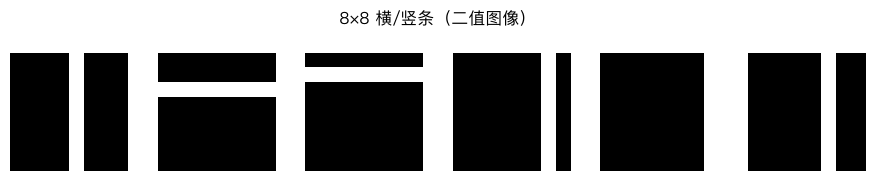

In [2]:
def make_bars(n=1000, seed=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 8, 8)); y = np.zeros(n, dtype=np.int64)
    for i in range(n):
        if rng.random() < 0.5:
            X[i, 0, rng.integers(0, 8), :] = 1.0; y[i] = 0
        else:
            X[i, 0, :, rng.integers(0, 8)] = 1.0; y[i] = 1
    return X, y

Xv, yv = make_bars()
print("数据:", Xv.shape)

fig, axes = plt.subplots(1, 6, figsize=(9, 1.8))
for i in range(6):
    axes[i].imshow(Xv[i, 0], cmap="gray"); axes[i].axis("off")
plt.suptitle("8×8 横/竖条（二值图像）")
plt.tight_layout(); plt.show()

In [3]:
class VAE(nn.Module):
    def __init__(self, d=64, h=32, latent=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.ReLU())
        self.mu = nn.Linear(h, latent)
        self.logvar = nn.Linear(h, latent)
        self.dec = nn.Sequential(nn.Linear(latent, h), nn.ReLU(), nn.Linear(h, d))
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + torch.exp(0.5 * logvar) * eps          # z = μ + σ·ε
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return torch.sigmoid(self.dec(z)), mu, logvar, z

def vae_loss(recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / len(x)
    kl = -0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(1).mean()   # 闭式 KL
    return recon_loss + kl, recon_loss, kl

model = VAE()
print("VAE 参数量:", sum(p.numel() for p in model.parameters()))

VAE 参数量: 4420


step    0  总loss=45.2794  重构=45.2241  KL=0.0553
step  300  总loss=25.2553  重构=23.9475  KL=1.3078
step  600  总loss=19.8542  重构=17.4814  KL=2.3727


step  900  总loss=17.2735  重构=14.0396  KL=3.2339
step 1200  总loss=12.2237  重构=7.7401  KL=4.4836


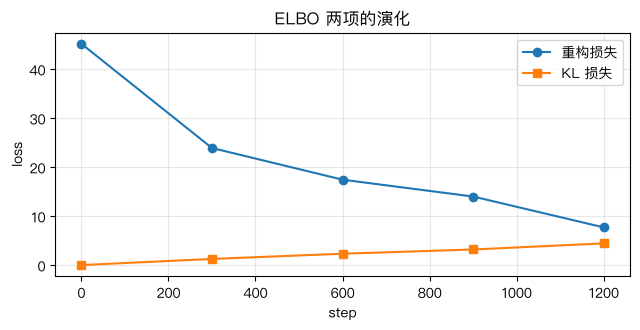

In [4]:
Xt = torch.tensor(Xv, dtype=torch.float32).reshape(-1, 64)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
n = len(Xt)
curve = []
for step in range(1500):
    idx = torch.randint(0, n, (64,))
    opt.zero_grad()
    recon, mu, logvar, _ = model(Xt[idx])
    loss, rl, kl = vae_loss(recon, Xt[idx], mu, logvar)
    loss.backward(); opt.step()
    if step % 300 == 0:
        curve.append((step, rl.item(), kl.item()))
        print(f"step {step:4d}  总loss={loss.item():.4f}  重构={rl.item():.4f}  KL={kl.item():.4f}")

st = [s for s, _, _ in curve]
plt.figure(figsize=(6.5, 3.4))
plt.plot(st, [r for _, r, _ in curve], "o-", label="重构损失")
plt.plot(st, [k for _, _, k in curve], "s-", label="KL 损失")
plt.xlabel("step"); plt.ylabel("loss"); plt.title("ELBO 两项的演化")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

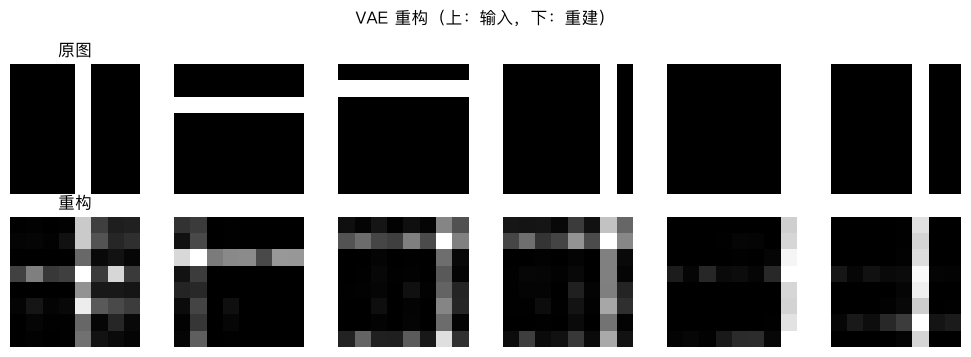

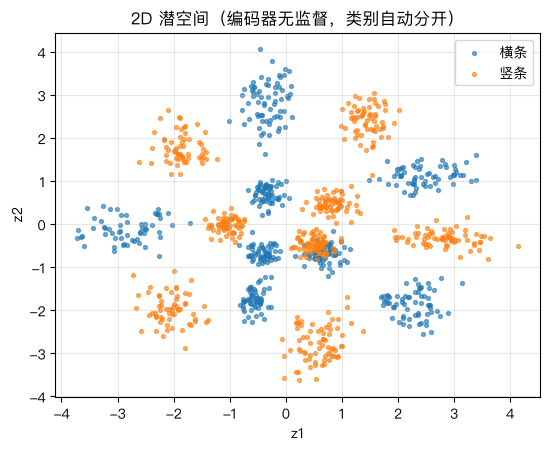

In [5]:
with torch.no_grad():
    recon, mu, logvar, z = model(Xt)
    recon = recon.numpy().reshape(-1, 8, 8)
    z = z.numpy()

# 重构 vs 原图
fig, axes = plt.subplots(2, 6, figsize=(10, 3.6))
for i in range(6):
    axes[0, i].imshow(Xv[i, 0], cmap="gray"); axes[0, i].set_title("原图" if i == 0 else ""); axes[0, i].axis("off")
    axes[1, i].imshow(recon[i], cmap="gray"); axes[1, i].set_title("重构" if i == 0 else ""); axes[1, i].axis("off")
plt.suptitle("VAE 重构（上：输入，下：重建）")
plt.tight_layout(); plt.show()

# 潜空间：类别自动聚类
plt.figure(figsize=(5.6, 4.6))
plt.scatter(z[yv == 0, 0], z[yv == 0, 1], s=8, alpha=0.6, label="横条")
plt.scatter(z[yv == 1, 0], z[yv == 1, 1], s=8, alpha=0.6, label="竖条")
plt.xlabel("z1"); plt.ylabel("z2"); plt.title("2D 潜空间（编码器无监督，类别自动分开）")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 潜空间插值：生成新样本

在 2D 潜空间铺一张网格 $z \in [-3, 3]^2$，逐点解码——观察**潜空间是连续的**：格子不同区域平滑过渡出横条/竖条/两者混合的中间形态。这就是"生成"：采样先验 → 解码。

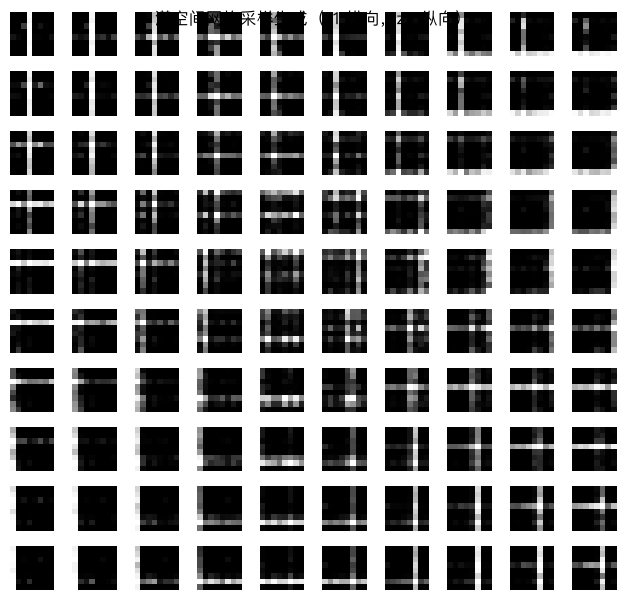

In [6]:
with torch.no_grad():
    g1 = np.linspace(-3, 3, 10); g2 = np.linspace(-3, 3, 10)
    grid = np.array([[a, b] for b in g2 for a in g1], dtype=np.float32)
    gen = torch.sigmoid(model.dec(torch.tensor(grid))).numpy().reshape(10, 10, 8, 8)

fig, axes = plt.subplots(10, 10, figsize=(6.4, 6.4))
for i in range(10):
    for j in range(10):
        axes[i, j].imshow(gen[i, j], cmap="gray")
        axes[i, j].axis("off")
plt.suptitle("潜空间网格采样生成（z1 横向，z2 纵向）", y=0.93)
plt.tight_layout(); plt.show()

## 总结

1. **ELBO = 重构 − KL**：两项的拉锯解释了一切——KL 项太强则生成好但重构模糊（欠拟合数据），太弱则重构好但潜空间有洞（生成垃圾）。
2. **重参数化**让"采样"变得可导，是 VAE 能反向传播的关键。
3. VAE 的进化：β-VAE（加重 KL 学解耦表示）、VQ-VAE（离散潜变量，Stable Diffusion 用的就是它）、Hierarchical VAE。

> Stable Diffusion 的"VAE 部分"：图像 → 8× 压缩潜空间（VQ-VAE）→ 在潜空间上跑扩散，而不是直接扩散像素——这就是它能在消费级 GPU 上训练/推理的原因之一（详见 07 课）。

## 课后练习

1. 把潜变量维度从 2 改成 8，观察重构质量与潜空间可视化的变化——维度越高越难可视化，但表示能力更强。
2. 给 KL 项加系数 β：`loss = recon + β·kl`，试 β=0.1 和 β=5，观察"重构好 vs 潜空间规整"的权衡。
3. 把解码器输出从 sigmoid 换成"伯努利采样"（生成时再采一次），体会"解码分布 vs 采样"的区别。